In [2]:
# To display columns of a DataFrame in a Jupyter notebook
import pandas as pd
import numpy as np
from collections import Counter
import re
from scipy import stats  # Make sure to import stats for McNemar's test
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib import rcParams

# Set up beautiful plot style
plt.rcParams['figure.facecolor'] = 'none'  # Transparent background
plt.rcParams['axes.facecolor'] = '#FFFFFF'    # White plot area
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']
plt.rcParams['axes.edgecolor'] = '#333333'    # Dark grey axes
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#DDDDDD'        # Light grey grid
plt.rcParams['grid.alpha'] = 0.6
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.2
plt.rcParams['savefig.transparent'] = True    # Enable transparency when saving

# Load data
dfgpt = pd.read_csv("gpt4o.csv")
dfqwen72b = pd.read_csv("qwen72b.csv")
dfqwen14b = pd.read_csv("qwen14b.csv")
dfllama70b = pd.read_csv("llama70b.csv")

print("Columns in dfgpt:")
print(dfgpt.columns.tolist())

print("Columns in dfqwen72b:")
print(dfqwen72b.columns.tolist())

print("Columns in dfqwen14b:")
print(dfqwen14b.columns.tolist())

print("Columns in dfllama70b:")
print(dfllama70b.columns.tolist())

# Rename columns to include model name as prefix to avoid column name conflicts
# For GPT-4o
dfgpt = dfgpt.rename(columns={
    'GPT_Round1': 'GPT4o_Round1',
    'GPT_Round2': 'GPT4o_Round2',
    'Ground Truth': 'Ground_Truth'
})

# For Qwen-72B (using actual column names)
dfqwen72b = dfqwen72b.rename(columns={
    'Qwen72B_Round 1': 'Qwen72B_Round1',
    'Qwen72B_Round 2': 'Qwen72B_Round2',
    'Ground_Truth': 'Ground_Truth'
})

# For Qwen-14B
dfqwen14b = dfqwen14b.rename(columns={
    'Qwen_14Round 1': 'Qwen14B_Round1',
    'Qwen_14Round 2': 'Qwen14B_Round2',
    'Ground_Truth_Answer': 'Ground_Truth'
})

# For Llama-70B
dfllama70b = dfllama70b.rename(columns={
    'Round 1': 'llamaRound1',
    'Round 2': 'llamaRound2',
    'Ground_Truth': 'Ground_Truth'
})

# Print updated column names
print("\nUpdated column names:")
print("GPT4o columns:", dfgpt.columns.tolist())
print("Qwen72B columns:", dfqwen72b.columns.tolist())
print("Qwen14B columns:", dfqwen14b.columns.tolist())
print("Llama70B columns:", dfllama70b.columns.tolist())

# Merge all dataframes on the "Origin" column
# Start with GPT4o
final_df = dfgpt.copy()

# Merge with Qwen72B
final_df = pd.merge(
    final_df, 
    dfqwen72b[['Origin', 'Qwen72B_Round1', 'Qwen72B_Round2', 'data_source']], 
    on='Origin', 
    how='outer'
)

# Merge with Qwen14B
final_df = pd.merge(
    final_df, 
    dfqwen14b[['Origin', 'Qwen14B_Round1', 'Qwen14B_Round2']], 
    on='Origin', 
    how='outer'
)

# If data_source is not yet in final_df (from Qwen72B), add it from Qwen14B
if 'data_source' not in final_df.columns and 'data_source' in dfqwen14b.columns:
    final_df = pd.merge(
        final_df,
        dfqwen14b[['Origin', 'data_source']],
        on='Origin',
        how='left'
    )

# For Llama70B, we need to rename the columns first, then merge
# Create a temporary dataframe with the columns renamed properly
llama_temp = dfllama70b.copy()
llama_temp = llama_temp.rename(columns={
    'LlamaRound 1': 'Llama70B_Round1',
    'LlamaRound 2': 'Llama70B_Round2'
})

# Merge with Llama70B using the temp dataframe
final_df = pd.merge(
    final_df, 
    llama_temp[['Origin', 'Llama70B_Round1', 'Llama70B_Round2']], 
    on='Origin', 
    how='outer'
)

# Ensure we have a single Ground_Truth column
ground_truth_cols = [col for col in final_df.columns if 'Ground_Truth' in col]
if len(ground_truth_cols) > 1:
    # Keep the first non-null value for each row
    final_df['Ground_Truth'] = final_df[ground_truth_cols].bfill(axis=1).iloc[:, 0]
    # Drop duplicate ground truth columns
    final_df = final_df.drop(columns=[col for col in ground_truth_cols if col != 'Ground_Truth'])

# Print info about the merged dataframe
print("\nMerged dataframe information:")
print(f"Number of rows: {len(final_df)}")
print(f"Number of columns: {len(final_df.columns)}")
print(f"Columns in final_df: {final_df.columns.tolist()}")

Columns in dfgpt:
['Origin', 'GPT_Round1', 'GPT_Round2', 'Ground Truth']
Columns in dfqwen72b:
['QA_ID', 'Origin', 'Qwen72B_Round 1', 'Qwen72B_Round 2', 'Ground_Truth', 'data_source']
Columns in dfqwen14b:
['Origin', 'data_source', 'Qwen_14Round 2', 'Qwen_14Round 1', 'Ground_Truth_Answer']
Columns in dfllama70b:
['QA_ID', 'Origin', 'LlamaRound 2', 'LlamaRound 1', 'Ground_Truth', 'data_source']

Updated column names:
GPT4o columns: ['Origin', 'GPT4o_Round1', 'GPT4o_Round2', 'Ground_Truth']
Qwen72B columns: ['QA_ID', 'Origin', 'Qwen72B_Round1', 'Qwen72B_Round2', 'Ground_Truth', 'data_source']
Qwen14B columns: ['Origin', 'data_source', 'Qwen14B_Round2', 'Qwen14B_Round1', 'Ground_Truth']
Llama70B columns: ['QA_ID', 'Origin', 'LlamaRound 2', 'LlamaRound 1', 'Ground_Truth', 'data_source']

Merged dataframe information:
Number of rows: 1300
Number of columns: 11
Columns in final_df: ['Origin', 'GPT4o_Round1', 'GPT4o_Round2', 'Ground_Truth', 'Qwen72B_Round1', 'Qwen72B_Round2', 'data_source', '


Sample of merged data (first 5 rows):
   Origin GPT4o_Round1 GPT4o_Round2 Ground_Truth Qwen72B_Round1  \
0  ID0002            D            D            D              D   
1  ID0003            D            D            G              G   
2  ID0007            A            B            B              A   
3  ID0009            D            D            D              D   
4  ID0010            H            H            H              H   

  Qwen72B_Round2 data_source Qwen14B_Round1 Qwen14B_Round2 Llama70B_Round1  \
0              D        jama              A              B               D   
1              G    medxpert              A              H               C   
2              A  medbullets              D              A               D   
3              B        jama              D              A               D   
4              H    medxpert              C              H               H   

  Llama70B_Round2  
0               D  
1               G  
2               A  
3        

FileNotFoundError: [Errno 2] No such file or directory: '/data/healthy-ml/scratch/yuexing/NeuRIPS25/After_PT_Removal/Result_Analysis_Final/accuracy_by_source.png'

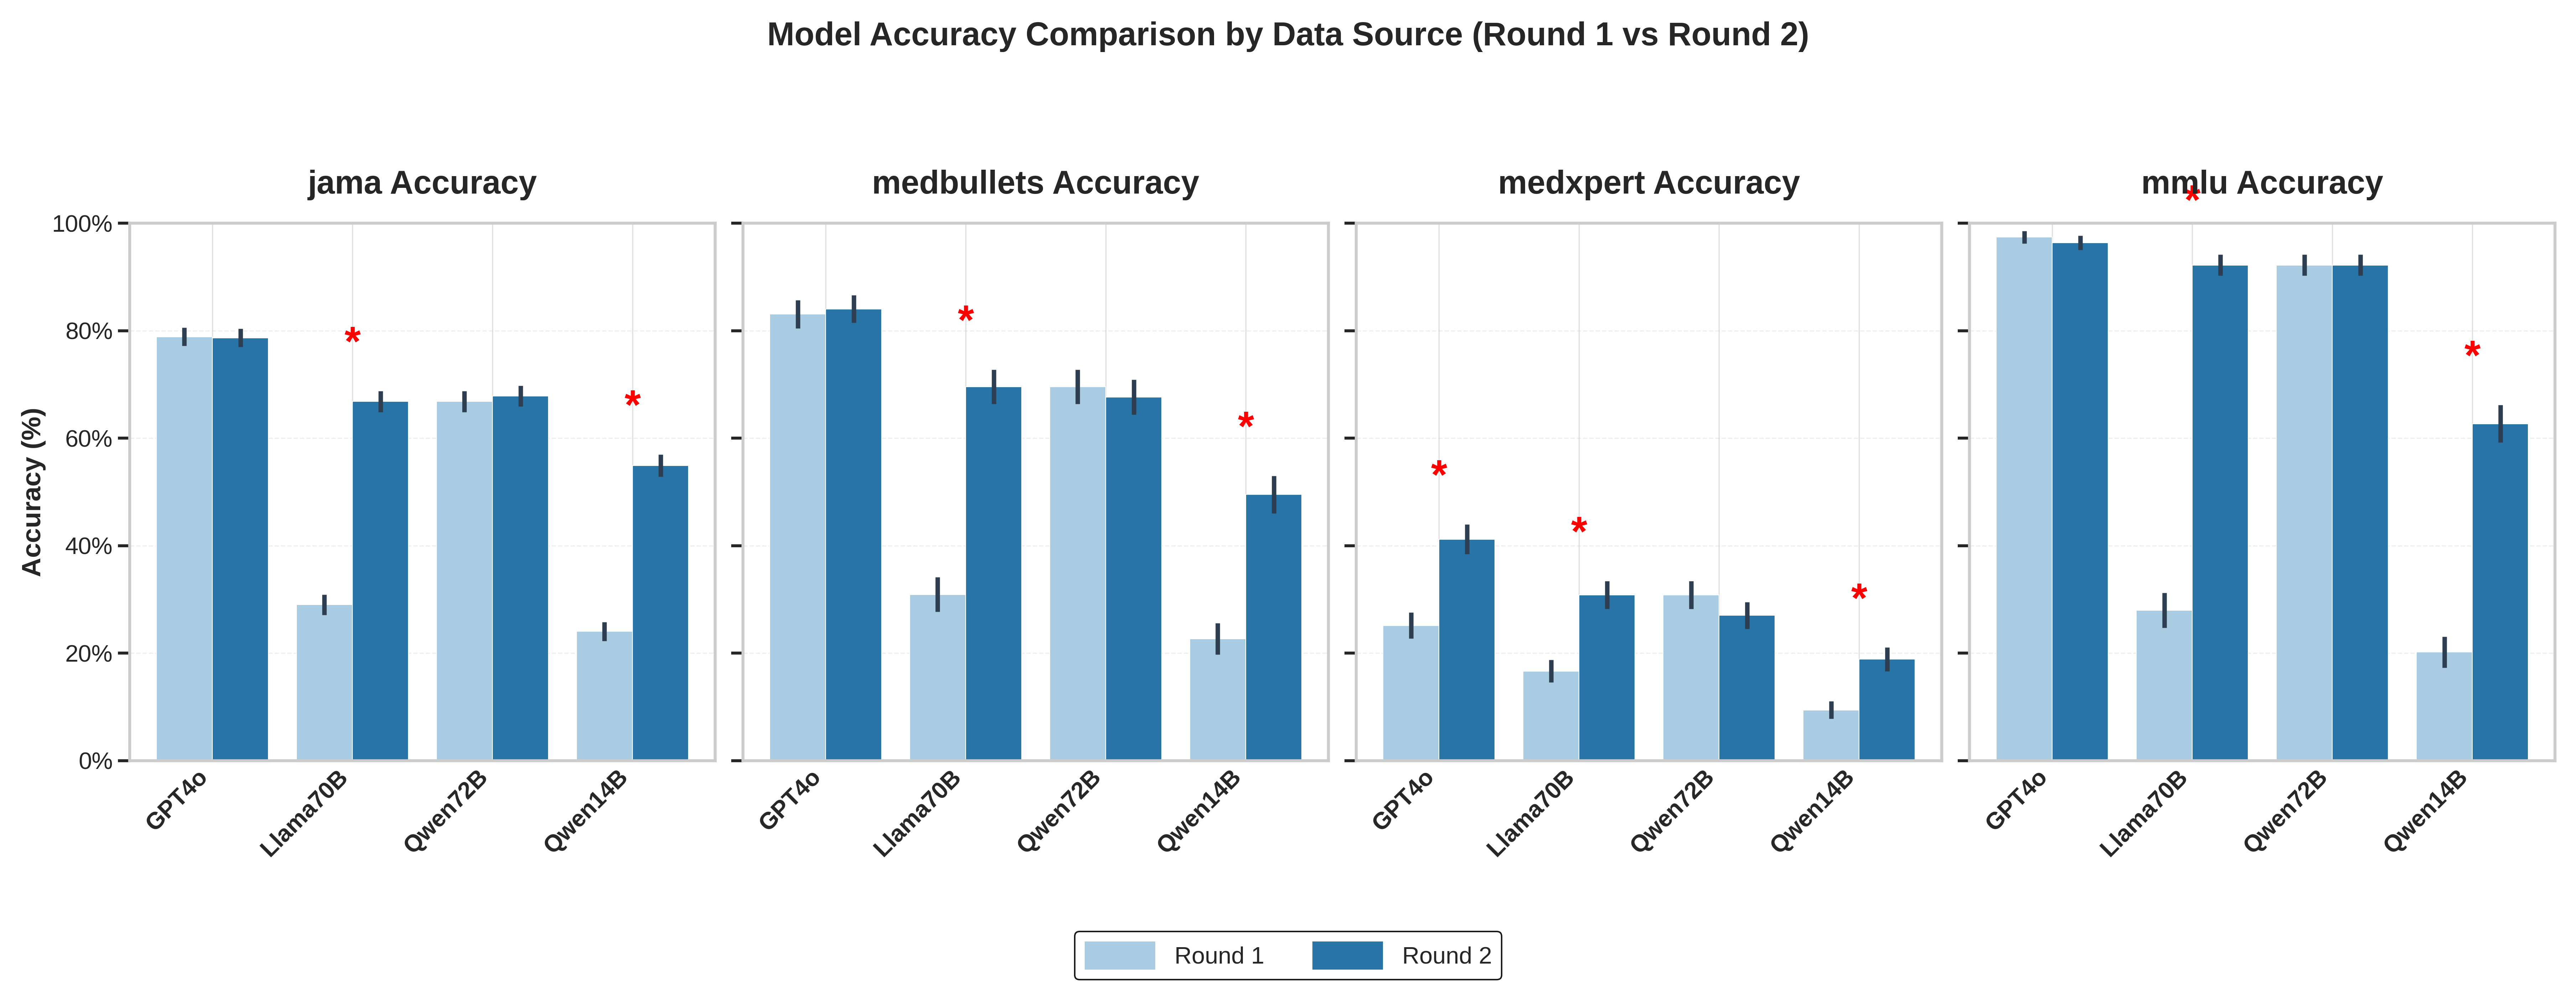

In [7]:

# # Save the merged dataframe
# final_df.to_csv("/data/healthy-ml/scratch/yuexing/NeuRIPS25/After_PT_Removal/Result_Analysis_Final/all_models_merged.csv", index=False)
# print("\nMerged data saved to 'all_models_merged.csv'")

# Print sample of the merged data
print("\nSample of merged data (first 5 rows):")
print(final_df.head(5))

# Function to save statistical results to CSV files
def save_results_to_csv(results_dict, filename):
    """
    Save results dictionary to a CSV file
    """
    with open(filename, 'w') as f:
        f.write(f"Model,Round,Correct,Total,Accuracy,StdDev\n")
        for model in sorted(results_dict.keys()):
            for round_num in ['Round1', 'Round2']:
                if round_num in results_dict[model]:
                    metrics = results_dict[model][round_num]
                    f.write(f"{model},{round_num},{metrics['correct']},{metrics['total']},"
                           f"{metrics['accuracy']:.4f},{metrics['std_dev']:.4f}\n")
    print(f"Results saved to {filename}")

def save_comparison_to_csv(df, filename):
    """
    Save model round comparisons to a CSV file
    """
    with open(filename, 'w') as f:
        f.write(f"Model,Round1_Acc,Round2_Acc,Difference,P_Value,Significant\n")
        for model in sorted(accuracy_metrics.keys()):
            if 'Round1' in accuracy_metrics[model] and 'Round2' in accuracy_metrics[model]:
                round1_acc = accuracy_metrics[model]['Round1']['accuracy']
                round2_acc = accuracy_metrics[model]['Round2']['accuracy']
                diff = round2_acc - round1_acc
                
                # Calculate statistical significance
                p_value, is_significant = perform_mcnemars_test(df, model)
                
                f.write(f"{model},{round1_acc:.4f},{round2_acc:.4f},{diff:.4f},{p_value:.6f},{is_significant}\n")
    print(f"Comparison saved to {filename}")

def save_pairwise_to_csv(df, filename):
    """
    Save pairwise model comparisons to a CSV file
    """
    models = sorted([model for model in accuracy_metrics.keys() if 'Round2' in accuracy_metrics[model]])
    
    with open(filename, 'w') as f:
        f.write(f"ModelA,ModelB,A_Accuracy,B_Accuracy,Difference,P_Value,Significant\n")
        for i, model_a in enumerate(models):
            for model_b in models[i+1:]:
                p_value, a_correct, b_correct, is_significant = compare_models(df, model_a, model_b)
                
                # Calculate accuracies
                total_rows = len(df.dropna(subset=['Ground_Truth', f"{model_a}_Round2", f"{model_b}_Round2"]))
                if total_rows > 0:
                    a_acc = a_correct / total_rows
                    b_acc = b_correct / total_rows
                    diff = a_acc - b_acc
                    
                    f.write(f"{model_a},{model_b},{a_acc:.4f},{b_acc:.4f},{diff:.4f},{p_value:.6f},{is_significant}\n")
    print(f"Pairwise comparison saved to {filename}")

# Function to calculate binary standard deviation
def binary_std(p, n):
    """
    Calculate standard deviation for a binary variable
    p: probability of success (accuracy)
    n: number of samples
    """
    if n == 0 or p == 0:
        return 0
    return (p * (1-p) / n) ** 0.5

# Function to calculate accuracy metrics for all models
def calculate_accuracy_metrics(df):
    models = ['GPT4o', 'Qwen72B', 'Qwen14B', 'Llama70B']
    rounds = ['Round1', 'Round2']
    
    # Create a results dictionary to store metrics
    results = {}
    
    for model in models:
        results[model] = {}
        for round_num in rounds:
            column = f"{model}_{round_num}"
            if column in df.columns:
                # Filter to rows with valid ground truth and prediction
                valid_rows = df.dropna(subset=['Ground_Truth', column])
                
                if len(valid_rows) > 0:
                    # Calculate accuracy
                    correct = (valid_rows[column] == valid_rows['Ground_Truth']).sum()
                    total = len(valid_rows)
                    accuracy = correct / total
                    std_dev = binary_std(accuracy, total)
                    
                    # Store results
                    results[model][round_num] = {
                        'correct': correct,
                        'total': total,
                        'accuracy': accuracy,
                        'std_dev': std_dev
                    }
                else:
                    results[model][round_num] = {
                        'correct': 0,
                        'total': 0,
                        'accuracy': 0,
                        'std_dev': 0
                    }
    
    return results

# Calculate accuracy metrics
print("\n" + "="*80)
print("ACCURACY ANALYSIS FOR ALL MODELS")
print("="*80)

accuracy_metrics = calculate_accuracy_metrics(final_df)

# Create a summary table
print("\nACCURACY SUMMARY TABLE:")
print(f"{'Model':<10} | {'Round':<6} | {'Correct':<8} | {'Total':<5} | {'Accuracy':<10} | {'Std Dev':<10}")
print("-" * 70)

for model in sorted(accuracy_metrics.keys()):
    for round_num in ['Round1', 'Round2']:
        if round_num in accuracy_metrics[model]:
            metrics = accuracy_metrics[model][round_num]
            print(f"{model:<10} | {round_num:<6} | {metrics['correct']:<8} | {metrics['total']:<5} | "
                  f"{metrics['accuracy']*100:<8.2f}% | {metrics['std_dev']*100:<8.2f}%")

# Calculate improvement between rounds for each model
print("\n" + "="*80)
print("IMPROVEMENT BETWEEN ROUNDS")
print("="*80)

print(f"{'Model':<10} | {'Round 1 Acc':<12} | {'Round 2 Acc':<12} | {'Difference':<10} | {'P-value':<10} | {'Significant':<10}")
print("-" * 85)

# Function to perform McNemar's test
def perform_mcnemars_test(df, model):
    """
    Perform McNemar's test to compare Round 1 and Round 2 for a model
    Returns p-value and whether the difference is statistically significant
    """
    round1_col = f"{model}_Round1"
    round2_col = f"{model}_Round2"
    
    # Filter to rows where we have both Round 1 and Round 2 predictions and Ground Truth
    valid_rows = df.dropna(subset=['Ground_Truth', round1_col, round2_col])
    
    if len(valid_rows) == 0:
        return 1.0, False  # No valid data for comparison
    
    # Calculate correctness
    round1_correct = valid_rows[round1_col] == valid_rows['Ground_Truth']
    round2_correct = valid_rows[round2_col] == valid_rows['Ground_Truth']
    
    # Contingency table
    # b: Round 1 incorrect, Round 2 correct (improved)
    # c: Round 1 correct, Round 2 incorrect (worsened)
    both_correct = (round1_correct & round2_correct).sum()
    both_incorrect = (~round1_correct & ~round2_correct).sum()
    r1_incorrect_r2_correct = (~round1_correct & round2_correct).sum()  # b
    r1_correct_r2_incorrect = (round1_correct & ~round2_correct).sum()  # c
    
    # For McNemar's test, we only care about discordant pairs (b and c)
    if r1_incorrect_r2_correct + r1_correct_r2_incorrect == 0:
        return 1.0, False  # No change between rounds
    
    # Apply continuity correction for McNemar's test
    # (|b - c| - 1)^2 / (b + c)
    statistic = (abs(r1_incorrect_r2_correct - r1_correct_r2_incorrect) - 1)**2 / (r1_incorrect_r2_correct + r1_correct_r2_incorrect)
    p_value = 1 - stats.chi2.cdf(statistic, df=1)  # 1 degree of freedom
    
    return p_value, p_value < 0.05

for model in sorted(accuracy_metrics.keys()):
    if 'Round1' in accuracy_metrics[model] and 'Round2' in accuracy_metrics[model]:
        round1_acc = accuracy_metrics[model]['Round1']['accuracy'] * 100
        round2_acc = accuracy_metrics[model]['Round2']['accuracy'] * 100
        diff = round2_acc - round1_acc
        
        # Calculate statistical significance
        p_value, is_significant = perform_mcnemars_test(final_df, model)
        
        print(f"{model:<10} | {round1_acc:<10.2f}% | {round2_acc:<10.2f}% | {diff:+10.2f}% | {p_value:<10.4f} | {'YES' if is_significant else 'NO':<10}")

# Also calculate pairwise model comparisons for Round 2
print("\n" + "="*80)
print("PAIRWISE MODEL COMPARISONS (ROUND 2)")
print("="*80)

models = sorted([model for model in accuracy_metrics.keys() if 'Round2' in accuracy_metrics[model]])
print(f"{'Model A':<10} | {'Model B':<10} | {'A Accuracy':<12} | {'B Accuracy':<12} | {'Difference':<10} | {'P-value':<10} | {'Significant':<10}")
print("-" * 100)

# Function to perform McNemar's test between two models
def compare_models(df, model_a, model_b, round_num="Round2"):
    """
    Perform McNemar's test to compare two models on the same round
    """
    col_a = f"{model_a}_{round_num}"
    col_b = f"{model_b}_{round_num}"
    
    # Filter to rows where we have both models' predictions and Ground Truth
    valid_rows = df.dropna(subset=['Ground_Truth', col_a, col_b])
    
    if len(valid_rows) == 0:
        return 1.0, 0, 0, False  # No valid data for comparison
    
    # Calculate correctness
    a_correct = valid_rows[col_a] == valid_rows['Ground_Truth']
    b_correct = valid_rows[col_b] == valid_rows['Ground_Truth']
    
    # Count correct predictions
    a_correct_count = a_correct.sum()
    b_correct_count = b_correct.sum()
    
    # Contingency table
    both_correct = (a_correct & b_correct).sum()
    both_incorrect = (~a_correct & ~b_correct).sum()
    a_correct_b_incorrect = (a_correct & ~b_correct).sum()
    a_incorrect_b_correct = (~a_correct & b_correct).sum()
    
    # For McNemar's test, we only care about discordant pairs
    if a_correct_b_incorrect + a_incorrect_b_correct == 0:
        return 1.0, a_correct_count, b_correct_count, False  # No difference
    
    # Apply continuity correction for McNemar's test
    statistic = (abs(a_correct_b_incorrect - a_incorrect_b_correct) - 1)**2 / (a_correct_b_incorrect + a_incorrect_b_correct)
    p_value = 1 - stats.chi2.cdf(statistic, df=1)  # 1 degree of freedom
    
    return p_value, a_correct_count, b_correct_count, p_value < 0.05

# Perform pairwise comparisons between models
for i, model_a in enumerate(models):
    for model_b in models[i+1:]:
        p_value, a_correct, b_correct, is_significant = compare_models(final_df, model_a, model_b)
        
        # Calculate accuracies
        total_rows = len(final_df.dropna(subset=['Ground_Truth', f"{model_a}_Round2", f"{model_b}_Round2"]))
        if total_rows > 0:
            a_acc = a_correct / total_rows * 100
            b_acc = b_correct / total_rows * 100
            diff = a_acc - b_acc
            
            print(f"{model_a:<10} | {model_b:<10} | {a_acc:<10.2f}% | {b_acc:<10.2f}% | {diff:+10.2f}% | {p_value:<10.4f} | {'YES' if is_significant else 'NO':<10}")

# Also analyze by data source if available
if 'data_source' in final_df.columns:
    print("\n" + "="*80)
    print("ANALYSIS BY DATA SOURCE")
    print("="*80)
    
    # Get unique data sources
    data_sources = final_df['data_source'].dropna().unique()
    
    for source in sorted(data_sources):
        print(f"\nDATA SOURCE: {source}")
        print("-" * 40)
        
        # Filter by data source
        source_df = final_df[final_df['data_source'] == source]
        
        # Calculate accuracy metrics for this source
        source_metrics = calculate_accuracy_metrics(source_df)
        
        # Display results with statistical significance
        print(f"{'Model':<10} | {'Round':<6} | {'Correct':<8} | {'Total':<5} | {'Accuracy':<10} | {'P-value':<10} | {'Significant':<10}")
        print("-" * 85)
        
        for model in sorted(source_metrics.keys()):
            # Only show models that have both rounds
            if 'Round1' in source_metrics[model] and 'Round2' in source_metrics[model] and source_metrics[model]['Round1']['total'] > 0:
                # Calculate statistical significance
                p_value, is_significant = perform_mcnemars_test(source_df, model)
                
                # Print Round 1
                metrics_r1 = source_metrics[model]['Round1']
                print(f"{model:<10} | {'Round1':<6} | {metrics_r1['correct']:<8} | {metrics_r1['total']:<5} | "
                     f"{metrics_r1['accuracy']*100:<8.2f}% | {'---':<10} | {'---':<10}")
                
                # Print Round 2 with p-value
                metrics_r2 = source_metrics[model]['Round2']
                print(f"{model:<10} | {'Round2':<6} | {metrics_r2['correct']:<8} | {metrics_r2['total']:<5} | "
                     f"{metrics_r2['accuracy']*100:<8.2f}% | {p_value:<10.4f} | {'YES' if is_significant else 'NO':<10}")
                
                # Print empty line for readability
                print()
        
        # Also add pairwise model comparison for this data source
        print("\nPAIRWISE MODEL COMPARISONS (ROUND 2) FOR SOURCE:", source)
        print("-" * 80)
        
        models = sorted([model for model in source_metrics.keys() 
                       if 'Round2' in source_metrics[model] and source_metrics[model]['Round2']['total'] > 0])
        
        if len(models) >= 2:
            print(f"{'Model A':<10} | {'Model B':<10} | {'A Accuracy':<12} | {'B Accuracy':<12} | {'Difference':<10} | {'P-value':<10} | {'Significant':<10}")
            print("-" * 100)
            
            for i, model_a in enumerate(models):
                for model_b in models[i+1:]:
                    p_value, a_correct, b_correct, is_significant = compare_models(source_df, model_a, model_b)
                    
                    # Calculate accuracies
                    total_rows = len(source_df.dropna(subset=['Ground_Truth', f"{model_a}_Round2", f"{model_b}_Round2"]))
                    if total_rows > 0:
                        a_acc = a_correct / total_rows * 100
                        b_acc = b_correct / total_rows * 100
                        diff = a_acc - b_acc
                        
                        print(f"{model_a:<10} | {model_b:<10} | {a_acc:<10.2f}% | {b_acc:<10.2f}% | {diff:+10.2f}% | {p_value:<10.4f} | {'YES' if is_significant else 'NO':<10}")
        else:
            print("Not enough models with data for this source to perform pairwise comparisons.")

# # Export all results to CSV files
# print("\n" + "="*80)
# print("EXPORTING RESULTS TO CSV FILES")
# print("="*80)

# # Save overall accuracy metrics
# save_results_to_csv(
#     accuracy_metrics, 
#     "/data/healthy-ml/scratch/yuexing/NeuRIPS25/After_PT_Removal/Result_Analysis_Final/accuracy_metrics.csv"
# )

# # Save round comparisons
# save_comparison_to_csv(
#     final_df,
#     "/data/healthy-ml/scratch/yuexing/NeuRIPS25/After_PT_Removal/Result_Analysis_Final/round_comparisons.csv"
# )

# # Save pairwise model comparisons
# save_pairwise_to_csv(
#     final_df,
#     "/data/healthy-ml/scratch/yuexing/NeuRIPS25/After_PT_Removal/Result_Analysis_Final/pairwise_comparisons.csv"
# )

# # If we have data sources, save per-source results too
# if 'data_source' in final_df.columns:
#     print("\nExporting per-source results:")
#     data_sources = final_df['data_source'].dropna().unique()
    
#     for source in sorted(data_sources):
#         source_df = final_df[final_df['data_source'] == source]
#         source_metrics = calculate_accuracy_metrics(source_df)
        
#         # Save source-specific metrics
#         save_results_to_csv(
#             source_metrics,
#             f"/data/healthy-ml/scratch/yuexing/NeuRIPS25/After_PT_Removal/Result_Analysis_Final/accuracy_metrics_{source}.csv"
#         )
        
#         # Save source-specific comparisons
#         save_comparison_to_csv(
#             source_df,
#             f"/data/healthy-ml/scratch/yuexing/NeuRIPS25/After_PT_Removal/Result_Analysis_Final/round_comparisons_{source}.csv"
#         )
        
#         # Save source-specific pairwise comparisons
#         save_pairwise_to_csv(
#             source_df,
#             f"/data/healthy-ml/scratch/yuexing/NeuRIPS25/After_PT_Removal/Result_Analysis_Final/pairwise_comparisons_{source}.csv"
#         )

# print("\nAnalysis complete! All results have been exported to CSV files.")

# Create visualizations
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

def create_accuracy_comparison_charts(df, output_file):
    """
    Create a visualization with subplots for each data source, showing Round 1 vs Round 2 
    accuracy for each model with significance markers
    """
    if 'data_source' not in df.columns:
        print("Cannot create data source visualizations: no data_source column found")
        return
    
    # Get unique data sources
    data_sources = sorted(df['data_source'].dropna().unique())
    
    # Define models in display order
    models = ['GPT4o', 'Llama70B', 'Qwen72B', 'Qwen14B']
    model_columns = {  # Map display names to dataframe column prefixes
        'GPT4o': 'GPT4o',
        'Llama70B': 'Llama70B',
        'Qwen72B': 'Qwen72B',
        'Qwen14B': 'Qwen14B'
    }
    
    # Use blue tones for both rounds
    # Round 1 in lighter blue
    round1_color = '#A9CCE3'  # Light blue
    # Round 2 in darker blue
    round2_color = '#2874A6'  # Darker blue
    
    # Set figure font sizes
    title_size = 22
    axis_label_size = 18
    tick_label_size = 16
    annotation_size = 28  # Increased size for the star
    legend_size = 16
    
    # Set figure style for better aesthetics
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Create figure with subplots
    fig, axes = plt.subplots(nrows=1, ncols=len(data_sources), figsize=(6*len(data_sources), 8), 
                            dpi=300, sharey=True, facecolor='none')
    
    # Add a subtle shadow effect to the figure
    fig.patch.set_alpha(0)
    
    # If only one data source, make axes iterable
    if len(data_sources) == 1:
        axes = [axes]
    
    # Set figure title
    fig.suptitle('Model Accuracy Comparison by Data Source (Round 1 vs Round 2)', 
                fontsize=title_size, y=1.05, fontweight='bold')
    
    # Track the maximum accuracy for y-axis scaling
    max_accuracy = 0
    
    # Set bar width - wider bars look more elegant
    bar_width = 0.4
    
    # Process each data source
    for i, source in enumerate(data_sources):
        ax = axes[i]
        source_df = df[df['data_source'] == source]
        
        # Calculate metrics for each model and round
        source_metrics = calculate_accuracy_metrics(source_df)
        
        # Set up bar positions
        x_positions = np.arange(len(models))
        
        # First plot all Round 1 bars
        for j, model in enumerate(models):
            col_prefix = model_columns[model]
            col = f"{col_prefix}_Round1"
            
            if model in source_metrics and 'Round1' in source_metrics[model] and source_metrics[model]['Round1']['total'] > 0:
                # Round 1 data
                r1_acc = source_metrics[model]['Round1']['accuracy'] * 100
                r1_std = source_metrics[model]['Round1']['std_dev'] * 100
                
                # Plot bar for Round 1 with lighter color
                r1_bar = ax.bar(x_positions[j] - bar_width/2, r1_acc, bar_width, 
                        yerr=r1_std, capsize=0, color=round1_color, 
                        label=f"Round 1" if i == 0 and j == 0 else None,
                        error_kw={'ecolor': '#2C3E50', 'elinewidth': 3, 'capthick': 0},
                        edgecolor='white', linewidth=0.5)
                
                # Update max accuracy for y-axis
                max_accuracy = max(max_accuracy, r1_acc + r1_std)
        
        # Then plot all Round 2 bars
        for j, model in enumerate(models):
            col_prefix = model_columns[model]
            col = f"{col_prefix}_Round2"
            
            if model in source_metrics and 'Round2' in source_metrics[model] and source_metrics[model]['Round2']['total'] > 0:
                # Round 2 data
                r2_acc = source_metrics[model]['Round2']['accuracy'] * 100
                r2_std = source_metrics[model]['Round2']['std_dev'] * 100
                
                # Plot bar for Round 2 with darker color
                r2_bar = ax.bar(x_positions[j] + bar_width/2, r2_acc, bar_width, 
                        yerr=r2_std, capsize=0, color=round2_color,
                        label=f"Round 2" if i == 0 and j == 0 else None,
                        error_kw={'ecolor': '#2C3E50', 'elinewidth': 3, 'capthick': 0},
                        edgecolor='white', linewidth=0.5)
                
                # Update max accuracy for y-axis
                max_accuracy = max(max_accuracy, r2_acc + r2_std)
                
                # Calculate if difference is significant
                if 'Round1' in source_metrics[model] and source_metrics[model]['Round1']['total'] > 0:
                    p_value, is_significant = perform_mcnemars_test(source_df, model)
                    
                    # Add significance marker if significant
                    if is_significant:
                        r1_acc = source_metrics[model]['Round1']['accuracy'] * 100
                        height = max(r1_acc, r2_acc) + max(r1_std, r2_std) + 5
                        ax.text(x_positions[j], height, '*', ha='center', va='bottom', 
                                fontsize=annotation_size, color='red', fontweight='bold')
        
        # Set the title and labels
        ax.set_title(f"{source} Accuracy", fontsize=title_size, fontweight='bold', pad=20)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=tick_label_size, fontweight='bold')
        
        if i == 0:  # Only the leftmost plot needs y-label
            ax.set_ylabel('Accuracy (%)', fontsize=axis_label_size, fontweight='bold')
        
        # Format y-axis as percentage
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        
        # Add grid lines for readability (lighter)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
        # Set tick parameters
        ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
        ax.tick_params(axis='y', which='major', length=8, width=2)
        
        # Add spines
        for spine in ax.spines.values():
            spine.set_linewidth(2)
            
        # Set background color for better contrast
        ax.set_facecolor('#FFFFFF')
    
    # Set y-axis limits with a little padding
    for ax in axes:
        ax.set_ylim(0, min(100, max_accuracy * 1.15))  # Max 100% with some padding
    
    # Add a legend
    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    legend = fig.legend(
        by_label.values(),
        by_label.keys(),
        loc='upper center',
        bbox_to_anchor=(0.5, 0),
        ncol=2,
        frameon=True,
        fontsize=legend_size,
        handlelength=3,
        handleheight=1.5,
        framealpha=0.9,
        edgecolor='black'
    )
    legend.get_frame().set_facecolor('#FFFFFF')
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    
    # Save the figure with higher resolution as PNG
    plt.savefig(output_file, dpi=300, bbox_inches='tight', transparent=True)
    print(f"Visualization saved to {output_file}")
    
    # Also save as PDF
    pdf_output = output_file.replace('.png', '.pdf')
    plt.savefig(pdf_output, format='pdf', bbox_inches='tight', transparent=True)
    print(f"Visualization saved to {pdf_output}")
    
    # Also create a separate overall plot (not split by data source)
    create_overall_accuracy_chart(df, output_file.replace('.png', '_overall.png'))

def create_overall_accuracy_chart(df, output_file):
    """
    Create an overall visualization showing Round 1 vs Round 2 accuracy 
    for each model, not split by data source
    """
    # Define models in display order
    models = ['GPT4o', 'Llama70B', 'Qwen72B', 'Qwen14B']
    model_columns = {  # Map display names to dataframe column prefixes
        'GPT4o': 'GPT4o',
        'Llama70B': 'Llama70B',
        'Qwen72B': 'Qwen72B',
        'Qwen14B': 'Qwen14B'
    }
    
    # Use blue tones for both rounds
    # Round 1 in lighter blue
    round1_color = '#A9CCE3'  # Light blue
    # Round 2 in darker blue
    round2_color = '#2874A6'  # Darker blue
    
    # Set figure font sizes
    title_size = 24
    axis_label_size = 20
    tick_label_size = 18
    annotation_size = 28  # Increased size for the star
    legend_size = 18
    
    # Set figure style for better aesthetics
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8), dpi=300, facecolor='none')
    
    # Add a subtle shadow effect to the figure
    fig.patch.set_alpha(0)
    
    # Set plot area background
    ax.set_facecolor('#FFFFFF')
    
    # Set figure title
    ax.set_title('Overall Model Accuracy Comparison\n(Round 1 vs Round 2)', 
                fontsize=title_size, fontweight='bold', pad=20)
    
    # Calculate metrics
    overall_metrics = calculate_accuracy_metrics(df)
    
    # Set up bar positions
    bar_width = 0.4  # Wider bars look more elegant
    x_positions = np.arange(len(models))
    
    # First plot all Round 1 bars
    for j, model in enumerate(models):
        col_prefix = model_columns[model]
        col = f"{col_prefix}_Round1"
        
        if model in overall_metrics and 'Round1' in overall_metrics[model] and overall_metrics[model]['Round1']['total'] > 0:
            # Round 1 data
            r1_acc = overall_metrics[model]['Round1']['accuracy'] * 100
            r1_std = overall_metrics[model]['Round1']['std_dev'] * 100
            
            # Plot bar for Round 1
            ax.bar(x_positions[j] - bar_width/2, r1_acc, bar_width, 
                   yerr=r1_std, capsize=0, color=round1_color, 
                   label="Round 1" if j == 0 else None,
                   error_kw={'ecolor': '#2C3E50', 'elinewidth': 3, 'capthick': 0},
                   edgecolor='white', linewidth=0.5)
    
    # Then plot all Round 2 bars
    for j, model in enumerate(models):
        col_prefix = model_columns[model]
        col = f"{col_prefix}_Round2"
        
        if model in overall_metrics and 'Round2' in overall_metrics[model] and overall_metrics[model]['Round2']['total'] > 0:
            # Round 2 data
            r2_acc = overall_metrics[model]['Round2']['accuracy'] * 100
            r2_std = overall_metrics[model]['Round2']['std_dev'] * 100
            
            # Plot bar for Round 2
            ax.bar(x_positions[j] + bar_width/2, r2_acc, bar_width, 
                   yerr=r2_std, capsize=0, color=round2_color,
                   label="Round 2" if j == 0 else None,
                   error_kw={'ecolor': '#2C3E50', 'elinewidth': 3, 'capthick': 0},
                   edgecolor='white', linewidth=0.5)
            
            # Calculate if difference is significant
            if 'Round1' in overall_metrics[model] and overall_metrics[model]['Round1']['total'] > 0:
                p_value, is_significant = perform_mcnemars_test(df, model)
                
                # Add significance marker if significant
                if is_significant:
                    r1_acc = overall_metrics[model]['Round1']['accuracy'] * 100
                    height = max(r1_acc, r2_acc) + max(r1_std, r2_std) + 5
                    ax.text(x_positions[j], height, '*', ha='center', va='bottom', 
                            fontsize=annotation_size, color='red', fontweight='bold')
    
    # Set labels
    ax.set_ylabel('Accuracy (%)', fontsize=axis_label_size, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(models, fontsize=tick_label_size, fontweight='bold')
    
    # Format y-axis as percentage
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    # Add grid lines for readability (lighter)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Set tick parameters
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.tick_params(axis='y', which='major', length=8, width=2)
    
    # Add spines
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    
    # Set y-axis limits
    ax.set_ylim(0, 100)
    
    # Add a legend with two columns (one for each round)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    legend = ax.legend(
        by_label.values(),
        by_label.keys(),
        loc='upper center',
        bbox_to_anchor=(0.5, -0.1),
        ncol=2,
        frameon=True,
        fontsize=legend_size,
        handlelength=3,
        handleheight=1.5,
        framealpha=0.9,
        edgecolor='black'
    )
    legend.get_frame().set_facecolor('#FFFFFF')
    
    # Add text annotation for statistical significance
    plt.figtext(0.5, -0.05, "* indicates statistically significant difference (p < 0.05)", 
                ha="center", fontsize=16, fontweight='bold', color='red')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the figure with higher resolution as PNG
    plt.savefig(output_file, dpi=300, bbox_inches='tight', transparent=True)
    print(f"Overall visualization saved to {output_file}")
    
    # Also save as PDF
    pdf_output = output_file.replace('.png', '.pdf')
    plt.savefig(pdf_output, format='pdf', bbox_inches='tight', transparent=True)
    print(f"Overall visualization saved to {pdf_output}")

# Generate visualizations
create_accuracy_comparison_charts(
    final_df, 
    "/data/healthy-ml/scratch/yuexing/NeuRIPS25/After_PT_Removal/Result_Analysis_Final/accuracy_by_source.png"
)

print("\nAnalysis complete! All results have been exported to CSV files and visualizations have been created.")



Plot saved as medical_datasets_comparison.pdf


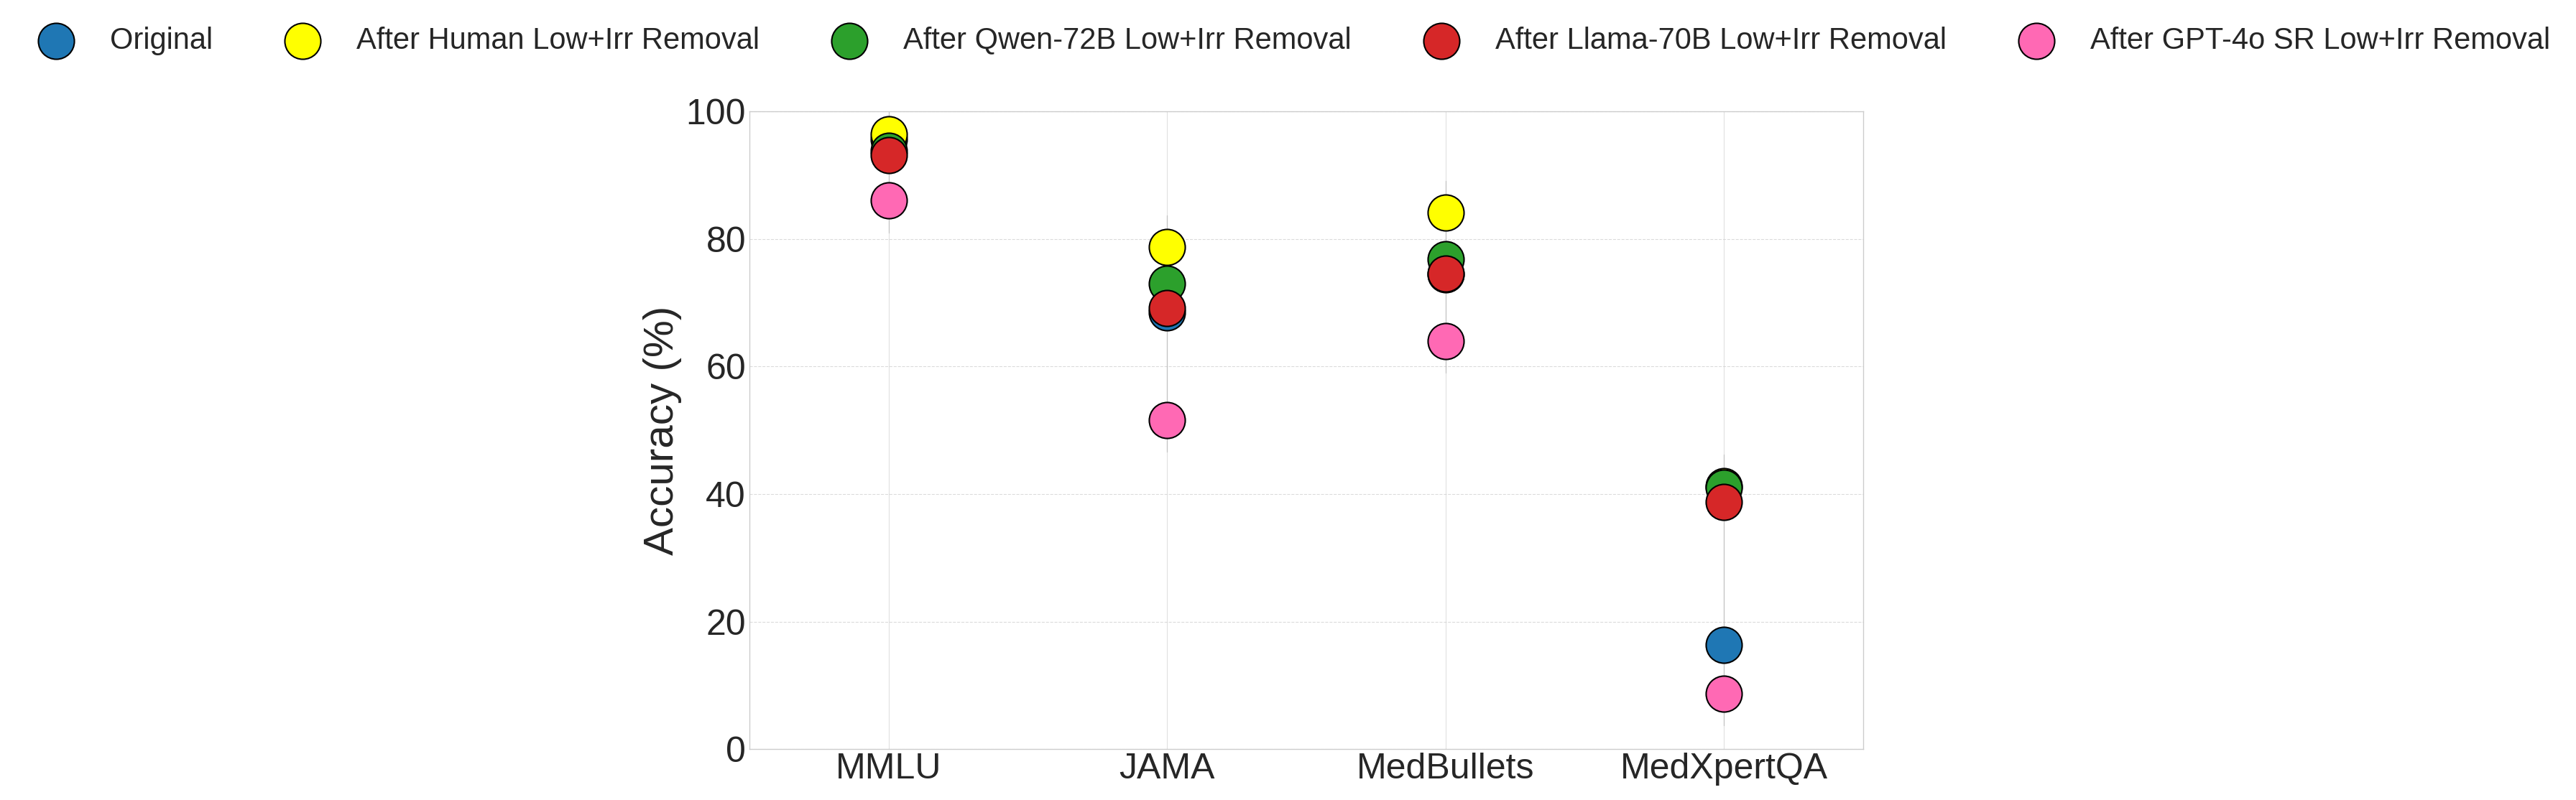

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dataset categories for x-axis (removing GPT-4o)
categories = ['MMLU', 'JAMA', 'MedBullets', 'MedXpertQA']

# Processing methods (vertical dots in each category)
methods = [
    'Original', 
    'After Human Low+Irr Removal', 
    'After Qwen-72B Low+Irr Removal',
    'After Llama-70B Low+Irr Removal',
    'After GPT-4o SR Low+Irr Removal'
]

# Actual data from the user's table with SD values
data = {
    'JAMA': {
        'Original': {'acc': 68.5, 'sd': 0.5},
        'After Human Low+Irr Removal': {'acc': 78.7, 'sd': 0.4},
        'After Qwen-72B Low+Irr Removal': {'acc': 73.0, 'sd': 0.3},
        'After Llama-70B Low+Irr Removal': {'acc': 69.2, 'sd': 0.5},
        'After GPT-4o SR Low+Irr Removal': {'acc': 51.6, 'sd': 0.5}
    },
    'MMLU': {
        'Original': {'acc': 95.6, 'sd': 0.4},
        'After Human Low+Irr Removal': {'acc': 96.4, 'sd': 0.4},
        'After Qwen-72B Low+Irr Removal': {'acc': 93.8, 'sd': 0.4},
        'After Llama-70B Low+Irr Removal': {'acc': 93.2, 'sd': 0.4},
        'After GPT-4o SR Low+Irr Removal': {'acc': 86.0, 'sd': 0.5}
    },
    'MedBullets': {
        'Original': {'acc': 74.5, 'sd': 0.4},
        'After Human Low+Irr Removal': {'acc': 84.1, 'sd': 0.5},
        'After Qwen-72B Low+Irr Removal': {'acc': 76.8, 'sd': 0.5},
        'After Llama-70B Low+Irr Removal': {'acc': 74.6, 'sd': 0.5},
        'After GPT-4o SR Low+Irr Removal': {'acc': 64.0, 'sd': 0.3}
    },
    'MedXpertQA': {
        'Original': {'acc': 16.4, 'sd': 0.4},
        'After Human Low+Irr Removal': {'acc': 41.2, 'sd': 0.5},
        'After Qwen-72B Low+Irr Removal': {'acc': 41.0, 'sd': 0.5},
        'After Llama-70B Low+Irr Removal': {'acc': 38.8, 'sd': 0.5},
        'After GPT-4o SR Low+Irr Removal': {'acc': 8.7, 'sd': 0.3}
    }
}

# Colors for each method (similar to the attached image)
colors = {
    'Original': '#1f77b4',  # Blue
    'After Human Low+Irr Removal': '#ffff00',  # Yellow (highlighted in the table)
    'After Qwen-72B Low+Irr Removal': '#2ca02c',  # Green
    'After Llama-70B Low+Irr Removal': '#d62728',  # Red
    'After GPT-4o SR Low+Irr Removal': '#ff69b4'  # Pink (highlighted in the table)
}

# Create figure and axis with larger dimensions
fig, ax = plt.subplots(figsize=(20, 12))

# Set positions for each category on x-axis
cat_positions = np.arange(len(categories))

# Function to calculate increase from original
def calculate_increase(cat, method):
    orig_acc = data[cat]['Original']['acc']
    curr_acc = data[cat][method]['acc']
    return curr_acc - orig_acc

# Increase circle size
circle_size = 1300

# Plot data points for each category
for i, cat in enumerate(categories):
    # Define vertical positions for each method within this category
    y_positions = {method: data[cat][method]['acc'] for method in methods}
    
    # Plot original point first
    orig_acc = y_positions['Original']
    ax.scatter(i, orig_acc, s=circle_size, color=colors['Original'], edgecolors='black', linewidth=1.5, zorder=3, 
              label='Original' if i == 0 else "")
    
    # Plot other points without annotations
    for method in methods[1:]:  # Skip original
        acc = y_positions[method]
        
        # Plot point with bigger circles
        ax.scatter(i, acc, s=circle_size, color=colors[method], edgecolors='black', linewidth=1.5, zorder=3,
                  label=method if i == 0 else "")
        
        # Add error bars
        ax.errorbar(i, acc, yerr=data[cat][method]['sd'], color=colors[method], capsize=5, linewidth=2, capthick=2)
    
    # Add error bars for original point too
    ax.errorbar(i, orig_acc, yerr=data[cat]['Original']['sd'], color=colors['Original'], capsize=5, linewidth=2, capthick=2)

# Draw vertical lines connecting points in each category
for i, cat in enumerate(categories):
    y_min = min([data[cat][method]['acc'] for method in methods])
    y_max = max([data[cat][method]['acc'] for method in methods])
    # Add padding to make the line extend slightly beyond the points
    padding = 5
    ax.plot([i, i], [y_min - padding, y_max + padding], color='gray', linestyle='-', linewidth=1, alpha=0.3)

# Customize the plot with 3x larger fonts
ax.set_ylim(0, 100)
ax.set_xlim(-0.5, len(categories) - 0.5)
ax.set_xticks(cat_positions)
ax.set_xticklabels(categories, fontsize=36)  # 3x larger font
ax.set_ylabel('Accuracy (%)', fontsize=42)  # 3x larger font
ax.tick_params(axis='y', labelsize=36)  # 3x larger Y-axis tick labels

# Add grid
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend (only once per method)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# Create a separate figure legend instead of trying to put it inside the axes
fig.legend(by_label.values(), by_label.keys(), 
           loc='upper center', bbox_to_anchor=(0.5, 0.98), 
           ncol=len(methods), fontsize=30)

# Add padding at the top for the legend
plt.subplots_adjust(top=0.85)

# Save the figure as PDF
output_filename = 'medical_datasets_comparison.pdf'
plt.savefig(output_filename, format='pdf', bbox_inches='tight')
print(f"Plot saved as {output_filename}") 